# Ejercicio Formativo 1 Capítulo 3

## Definiciones y objetivo de ayudantía:

### ¿Qué es el Machine Learning? ##
Machine Learning es una rama de la inteligencia artificial que se enfoca en desarrollar algoritmos capaces de **aprender automáticamente** a partir de los datos y mejorar su rendimiento sin necesidad de ser programados explícitamente para cada tarea. El objetivo de estos algoritmos es detectar patrones en los datos para luego hacer **predicciones** o **decisiones** basadas en nueva información.

### Componentes claves de ML: #
 -  **Datos**: Los modelos de ML necesitan datos para aprender. Estos datos suelen estar compuestos por características (o atributos) que describen el problema, y en algunos casos, etiquetas que representan las respuestas correctas.

 -  **Modelos**: Los algoritmos procesan los datos para construir modelos matemáticos que puedan hacer predicciones sobre datos nuevos

 -  **Entrenamiento**: El modelo se entrena con un conjunto de datos de ejemplo, ajustando sus parámetros para mejorar su precisión.

 -  **Generalización**: Un buen modelo de ML es capaz de generalizar su aprendizaje a datos no vistos, es decir, funciona bien no solo en los datos de entrenamiento, sino también en nuevos datos.

### Tipos de Machine Learning: ##

### *Aprendizaje supervisado*:  
El modelo se entrena con datos etiquetados (donde las respuestas son conocidas).  
**Por ejemplo**:  
En un sistema de **control de tráfico urbano**, se entrena un modelo para predecir el **flujo de vehículos** en distintas intersecciones utilizando datos históricos de tráfico, tiempo y eventos (como festivales o deportes). Las etiquetas serían la cantidad de vehículos que han cruzado la intersección en un tiempo específico, lo que permite optimizar los tiempos de los semáforos, reduciendo así los embotellamientos.

### *Aprendizaje no supervisado*:  
El modelo trabaja con datos no etiquetados, buscando patrones ocultos.  
**Por ejemplo**:  
En un **aeropuerto**, se pueden utilizar algoritmos de clustering para analizar el movimiento de pasajeros sin etiquetas predefinidas. El modelo puede identificar **patrones de congestión** en áreas específicas (como zonas de espera o tiendas), ayudando a mejorar el diseño de las instalaciones o la disposición de los servicios para mejorar la experiencia del usuario y optimizar los flujos de pasajeros.

## Definiciones adicionales: ##
### *Etiquetas*:  
Las etiquetas se utilizan en tareas de clasificación para entrenar modelos que puedan predecir a qué categoría pertenece una nueva observación basada en sus características.
### *Clustering*:
**Clustering** (o **agrupamiento**) es una técnica de aprendizaje no supervisado en la que se agrupan las observaciones en grupos o clústeres basados en características similares, sin tener etiquetas predefinidas. El objetivo del clustering es descubrir la estructura subyacente de los datos dividiéndolos en grupos en los que las observaciones dentro de un mismo grupo son más similares entre sí que con las observaciones de otros grupos.


## Objetivo de ayudantía: ##
Aplicar los conceptos teóricos a problemas prácticos en Python, utilizando bibliotecas como Pandas, scikit-learn y técnicas de Machine Learning (ML).



## Importando librerias

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


## Misión 1: completando información

Cargar archivo CSV utilizando pandas.

In [32]:
df = pd.read_csv("E1_datos.csv")
df.head()

,Unnamed: 0,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Ver que columnas son numéricas y cuales categóricas.

In [33]:
df.dtypes

,0
Unnamed: 0,int64
species,object
island,object
culmen_length_mm,float64
culmen_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


Contar los valores NaN.

In [34]:
df.isna().sum()

,0
Unnamed: 0,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,36
body_mass_g,2
sex,10


Completar las columnas numéricas con el promedio correspondiente.

In [35]:
col_numericas = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in col_numericas:
    df[col] = df[col].fillna(df[col].mean())

Eliminar los valores faltantes para las columnas categóricas.

In [36]:
col_categoricas = ['species', 'island', 'sex']
df = df.dropna(subset=col_categoricas)

Eliminación de columna "Unnamed: 0", la cual representaba la cantidad de muestras.

In [37]:
df = df.drop(columns=["Unnamed: 0"])

Verificar el resultado.

In [38]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [39]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


## Misión 2: preparación de los datos

### Prevención de Data **Leakage**

El **data leakage** (fuga de datos) es un problema común en Machine Learning que ocurre cuando el modelo tiene acceso a información del conjunto de prueba durante el proceso de entrenamiento. Esto puede hacer que el modelo parezca más preciso de lo que realmente es cuando se implementa en datos nuevos.

A continuación, explicamos cómo el código implementado evita este problema:

### 1. Codificación numérica de variables categóricas
Para evitar el data leakage, la codificación de las variables categóricas con **OneHotEncoder** se realiza **solo en el conjunto de entrenamiento**. De esta manera, los valores categóricos del conjunto de prueba no influyen en el entrenamiento del modelo. Si el codificador fuera ajustado con datos del conjunto de prueba, el modelo podría aprender patrones que están presentes en el conjunto de prueba pero no en el conjunto de entrenamiento, lo que introduciría un sesgo.

```python
# Codificación de variables categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),  # Escalamiento de variables numéricas
        ('cat', OneHotEncoder(), categorical_columns)  # Codificación one-hot para variables categóricas
    ]
)

X_transformed = preprocessor.fit_transform(X_train)


In [40]:
# Mostrar las columnas disponibles en el DataFrame
print("Columnas disponibles:", df.columns)

# Definir columnas categóricas y numéricas
categorical_columns = ['island', 'sex']  # Eliminamos 'species' ya que es la variable objetivo
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Paso 1: Codificación numérica de variables categóricas
# Crear un preprocesador para las variables numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),  # Escalamiento de variables numéricas
        ('cat', OneHotEncoder(), categorical_columns)  # Codificación one-hot para variables categóricas
    ]
)

# Definir las etiquetas (y) y las características (X)
y = df["species"]  # Variable objetivo
X = df.drop(columns=["species"])  # Características

# Asegurarse de que X e y tienen el mismo número de filas
print(f'Número de filas en X: {X.shape[0]}')
print(f'Número de filas en y: {y.shape[0]}')

# Aplicar la transformación a las características
X_transformed = preprocessor.fit_transform(X)

# Paso 2: Separación en conjuntos de entrenamiento y test
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# Verificar el tamaño de los conjuntos de entrenamiento y prueba
print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')

Columnas disponibles: Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
Número de filas en X: 334
Número de filas en y: 334
Tamaño del conjunto de entrenamiento: 267 muestras
Tamaño del conjunto de prueba: 67 muestras


## Misión 3: análisis exploratorio visual

Valores codificados de y: [0 1 2]
Forma de X_pca: (334, 2)


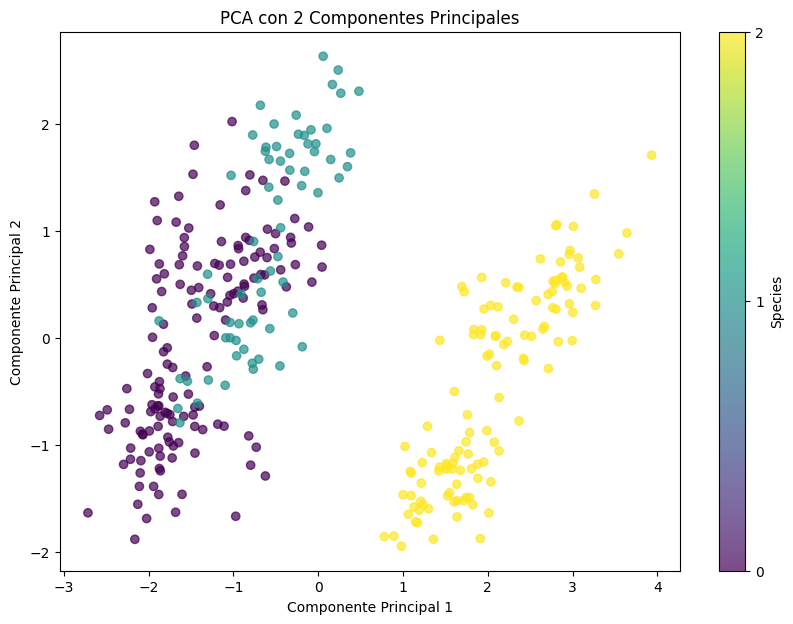

In [41]:
# Paso 1: Convertir las etiquetas categóricas en numéricas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Asegúrate de que y_encoded es un array numérico
print(f'Valores codificados de y: {np.unique(y_encoded)}')

# Paso 2: Crear un scatter plot usando los valores numéricos de las etiquetas
plt.figure(figsize=(10, 7))

# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Confirmar la forma del resultado
print("Forma de X_pca:", X_pca.shape)

# Scatter plot de los componentes principales usando las etiquetas numéricas
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)

# Agregar la barra de color
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species')
plt.title('PCA con 2 Componentes Principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()


En este análisis, utilizamos técnicas de reducción de dimensionalidad para visualizar nuestros datos. En particular, aplicamos Análisis de Componentes Principales (PCA) para reducir las dimensiones de los datos a 2 componentes principales. Esto facilita la visualización en un scatter plot, permitiéndonos observar patrones, clusters y posibles outliers.

### Descripción del Código

El código a continuación realiza los siguientes pasos:

1. **Codificación de Etiquetas:**
   - Utilizamos `LabelEncoder` para transformar las etiquetas categóricas (`species`) en valores numéricos. Esto es necesario porque las técnicas de visualización requieren que los datos sean numéricos.

2. **Transformación PCA:**
   - Aplicamos PCA a nuestros datos para reducir la dimensionalidad de las características a 2 componentes principales. Esta reducción nos permite visualizar los datos en un espacio bidimensional.

3. **Visualización:**
   - Creamos un scatter plot donde cada punto representa una observación en el espacio de las dos componentes principales.
   - El color de cada punto está determinado por la etiqueta de la especie, utilizando los valores numéricos obtenidos de `LabelEncoder`.

## Análisis de Componentes Principales (PCA)

En el Análisis de Componentes Principales (PCA), las **Componentes Principales** son nuevas variables que se obtienen al transformar las características originales del conjunto de datos. Estas nuevas variables son combinaciones lineales de las características originales y se ordenan de manera que las primeras componentes expliquen la mayor parte de la variabilidad en los datos.

### Componentes Principales 1 y 2

- **Componente Principal 1 (PC1)**: Esta es la primera dirección de máxima varianza en el conjunto de datos. En otras palabras, es la dirección en la que los datos tienen la mayor dispersión o variabilidad. El primer componente principal captura la mayor parte de la información disponible en los datos y es la variable más importante para la representación del conjunto de datos.

- **Componente Principal 2 (PC2)**: Esta es la segunda dirección de máxima varianza, ortogonal a la primera. Captura la mayor parte de la variabilidad en los datos que no está capturada por la primera componente principal. Aunque PC2 no explica tanta variabilidad como PC1, sigue siendo importante para entender la estructura de los datos.

### ¿Qué simbolizan?

En el scatter plot generado por PCA, las Componentes Principales 1 y 2 representan las dos dimensiones en las que los datos han sido proyectados. Estos componentes permiten visualizar y analizar la estructura de los datos en un espacio de dos dimensiones, en lugar del espacio original de múltiples dimensiones.

- **Componente Principal 1 (PC1)**: Representa la dimensión en la que los datos están más dispersos a lo largo de la dirección de máxima variabilidad.
- **Componente Principal 2 (PC2)**: Representa la dimensión ortogonal a PC1, mostrando la variabilidad adicional que no se captura en PC1.

### Interpretación en el Scatter Plot

En el scatter plot:

- El eje horizontal representa **Componente Principal 1 (PC1)**.
- El eje vertical representa **Componente Principal 2 (PC2)**.
- Los puntos están coloreados según las etiquetas codificadas (por ejemplo, especies de pájaros) para visualizar cómo se distribuyen las diferentes categorías a lo largo de estos dos componentes principales.

Este análisis ayuda a identificar patrones y agrupaciones en los datos, así como a observar la relación entre las diferentes etiquetas en un espacio reducido, facilitando la comprensión de la estructura subyacente en el conjunto de datos.


"Realice un análisis visual utilizando técnicas de reducción de dimensionalidad, con el fin de caracterizar
los datos. Para esto, inicialmente reduzca la dimensionalidad del espacio de características a 2 o 3
dimensiones y grafíquelos con un scatter plot, utilizando la etiqueta de los datos como color de los marcadores.
Analice distintos métodos de reducción de dimensionalidad, comentando sobre los grupos generados y la
existencia de outliers."

## Misión 4: análisis de clusters

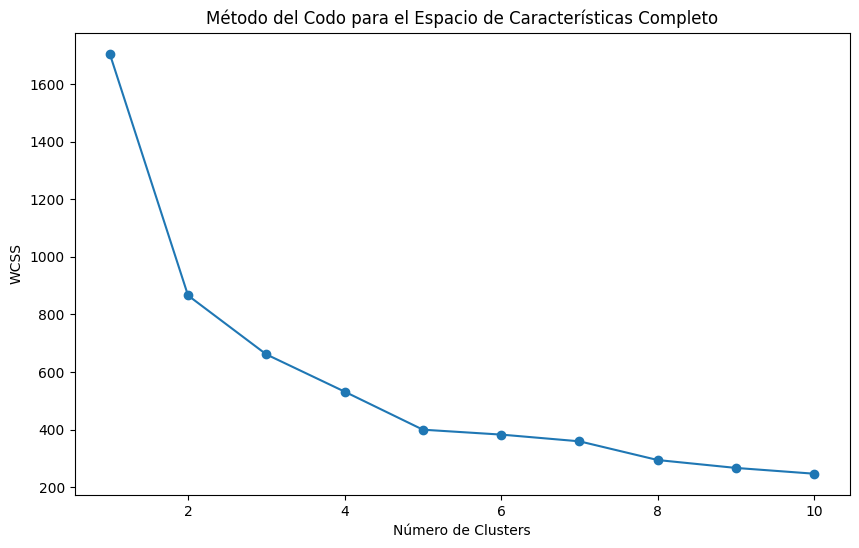

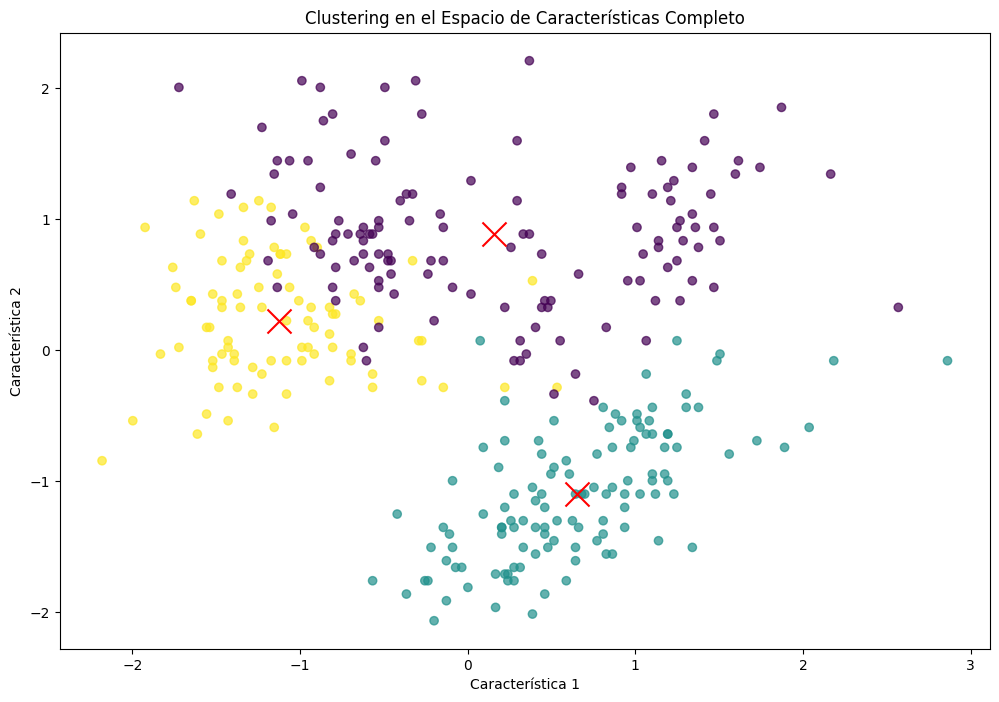

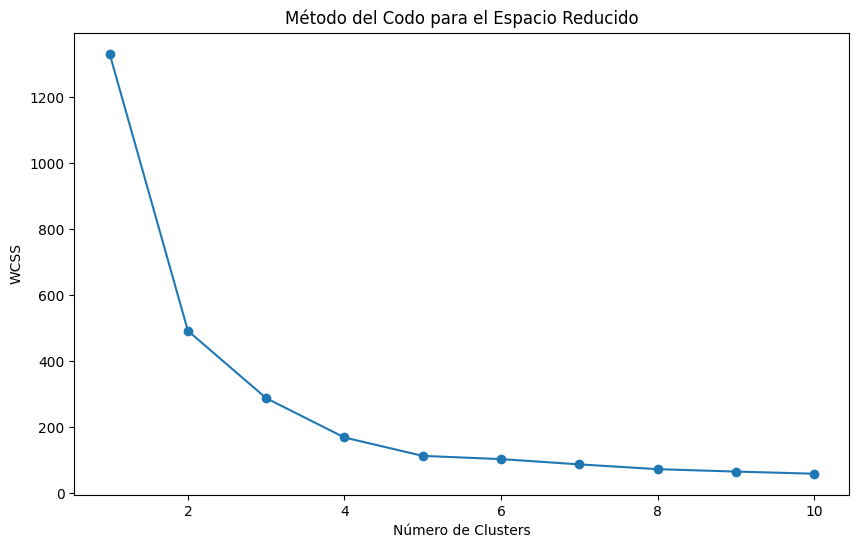

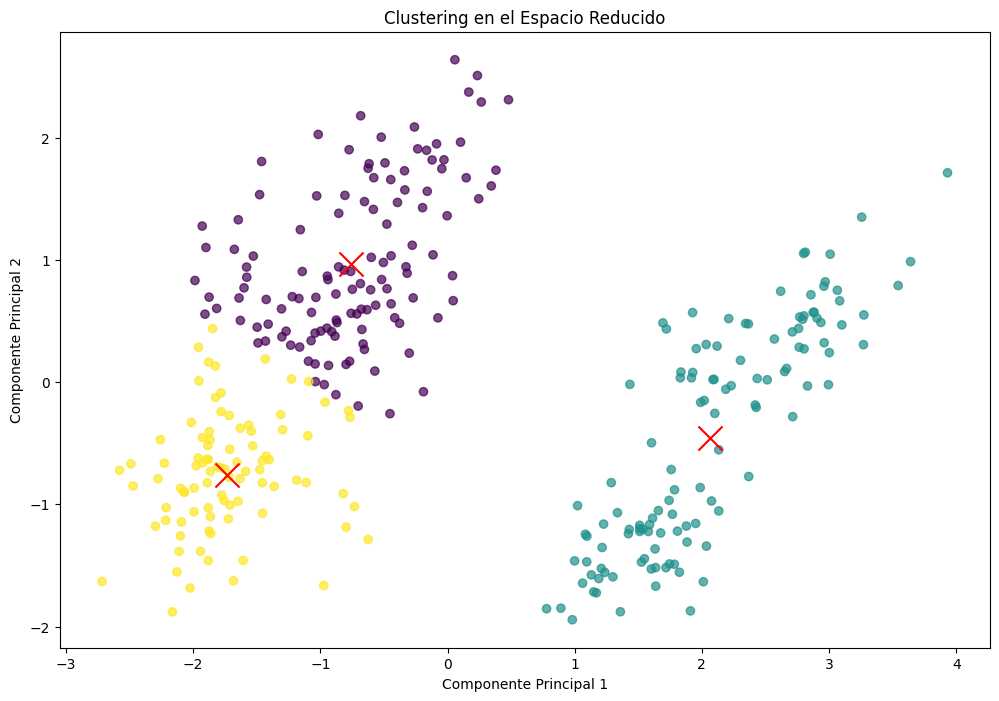

In [42]:
# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Paso 1: Clustering en el espacio de características completo
# Encontrar el número óptimo de clusters usando el Método del Codo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_transformed)
    wcss.append(kmeans.inertia_)

# Graficar el Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo para el Espacio de Características Completo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# Suponiendo que el número óptimo de clusters es 3 (ajusta según el gráfico del codo)
optimal_clusters = 3

# Aplicar K-Means con el número óptimo de clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters = kmeans.fit_predict(X_transformed)

# Visualización del Clustering en el Espacio de Características Completo
plt.figure(figsize=(12, 8))
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=clusters, cmap='viridis', alpha=0.7)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='x')
plt.title('Clustering en el Espacio de Características Completo')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Paso 2: Clustering en el espacio reducido (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Encontrar el número óptimo de clusters usando el Método del Codo en el espacio reducido
wcss_reduced = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss_reduced.append(kmeans.inertia_)

# Graficar el Método del Codo en el espacio reducido
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_reduced, marker='o')
plt.title('Método del Codo para el Espacio Reducido')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# Aplicar K-Means con el número óptimo de clusters en el espacio reducido
kmeans_reduced = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters_reduced = kmeans_reduced.fit_predict(X_pca)

# Visualización del Clustering en el Espacio Reducido
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_reduced, cmap='viridis', alpha=0.7)
centroids_reduced = kmeans_reduced.cluster_centers_
plt.scatter(centroids_reduced[:, 0], centroids_reduced[:, 1], s=300, c='red', marker='x')
plt.title('Clustering en el Espacio Reducido')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### Método del Codo

El **Método del Codo** es una técnica comúnmente utilizada para determinar el número óptimo de clusters en un conjunto de datos al aplicar algoritmos de clustering como K-Means. El objetivo principal de este método es identificar el punto en el que la adición de más clusters no mejora significativamente el modelo. Aquí se detalla cómo funciona y cómo se aplica:

### Concepto

El Método del Codo se basa en la idea de que a medida que aumentamos el número de clusters, la variación dentro del cluster (o la suma de los errores cuadráticos dentro del cluster, conocida como WCSS por sus siglas en inglés, "Within-Cluster Sum of Squares") disminuye. Esto ocurre porque los datos se agrupan en clusters más pequeños y, por lo tanto, la distancia entre los puntos de datos y el centro del cluster disminuye. Sin embargo, después de cierto número de clusters, la mejora en la reducción de WCSS se vuelve marginal. Este punto de disminución rápida es conocido como el "codo" en la gráfica.

### Método del codo: Elección del número óptimo de clústeres

El número óptimo de clústeres en el método del codo se elige al observar la relación entre el número de clústeres y la suma de los errores cuadráticos dentro de los clústeres (SSE, por sus siglas en inglés). A continuación se explica en más detalle por qué 3 es el número óptimo de clústeres en este caso:

#### Método del codo explicado
Cuando se aplica el algoritmo de K-Means, la métrica SSE mide la distancia entre los puntos dentro de un clúster y su centroide. A medida que se aumenta el número de clústeres, la SSE disminuye, ya que los puntos están más cerca de sus respectivos centroides.

- Al principio, añadir más clústeres provoca una gran reducción en el SSE, ya que se capturan mejor las diferencias entre grupos.
- Sin embargo, llega un punto donde añadir más clústeres no mejora significativamente la reducción del SSE. Este punto, que parece un "codo" en la gráfica, es donde se observa una disminución notablemente menor en la SSE al añadir clústeres adicionales.

#### Por qué 3 es el número óptimo
Al trazar el SSE contra el número de clústeres, se verá una curva descendente. En este caso, la gráfica presenta un claro codo en 3 clústeres. Esto significa que:

1. **Antes de 3 clústeres**: El SSE disminuye considerablemente con la adición de cada nuevo clúster. Esto sugiere que los puntos en los datos se agrupan mejor y que hay diferencias significativas entre los grupos formados.
   
2. **En 3 clústeres**: Se observa un punto de inflexión. El SSE todavía disminuye, pero con una menor pendiente. Este codo indica que los 3 clústeres son suficientes para capturar la mayor parte de la variabilidad en los datos, y que más clústeres no aportarían una mejora significativa.

3. **Más de 3 clústeres**: Aumentar el número de clústeres después de 3 solo reduce ligeramente el SSE, lo cual sugiere que los grupos adicionales no aportan un valor claro, ya que los datos no presentan diferencias tan marcadas más allá de este punto. De hecho, añadir más clústeres podría fragmentar innecesariamente los grupos existentes.

En resumen, el número óptimo de clústeres es 3 porque captura adecuadamente las relaciones en los datos sin agregar una complejidad innecesaria, y a partir de ahí, los beneficios de más clústeres son marginales en términos de reducción del SSE.


### Versión integrada (código completo) #

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
Filas con al menos un valor NaN: 0
Se eliminaron 0 filas por valores NaN en columnas categóricas.
Tamaño del conjunto de entrenamiento: 267 muestras
Tamaño del conjunto de prueba: 67 muestras
Valores codificados de y: [0 1 2]


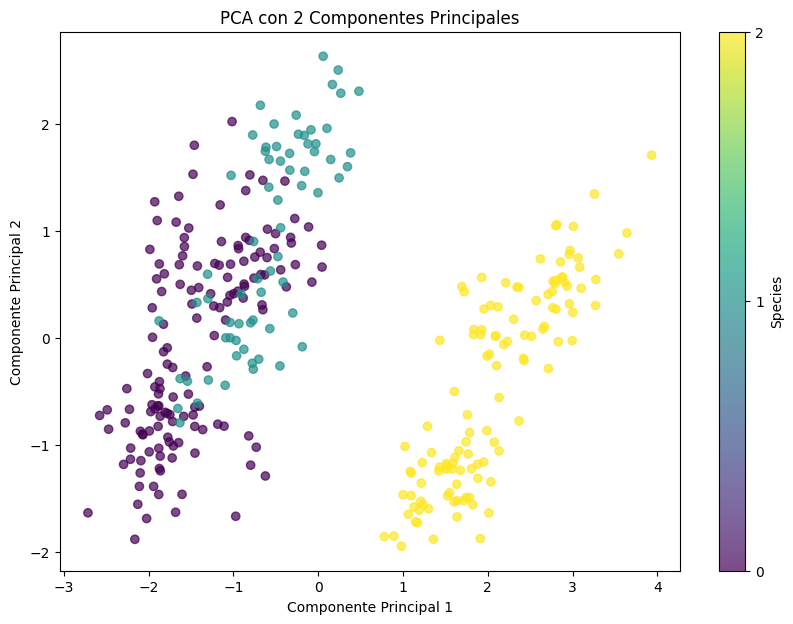

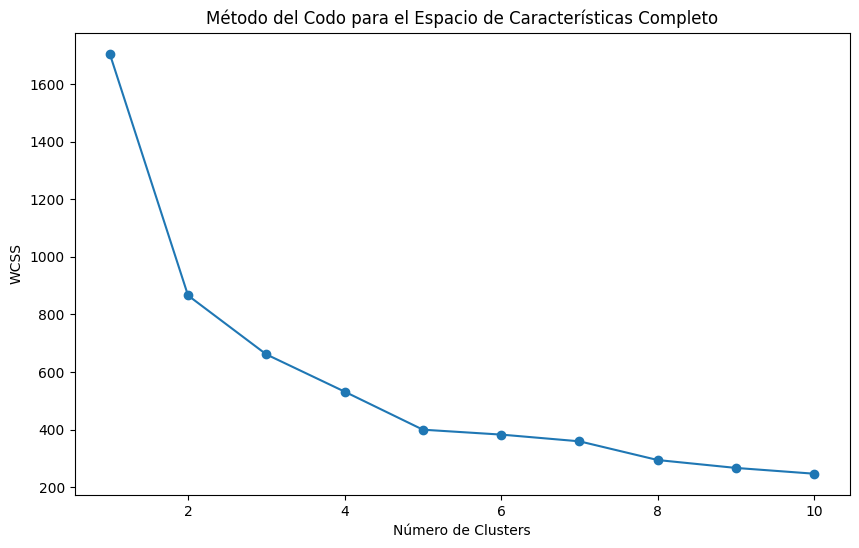

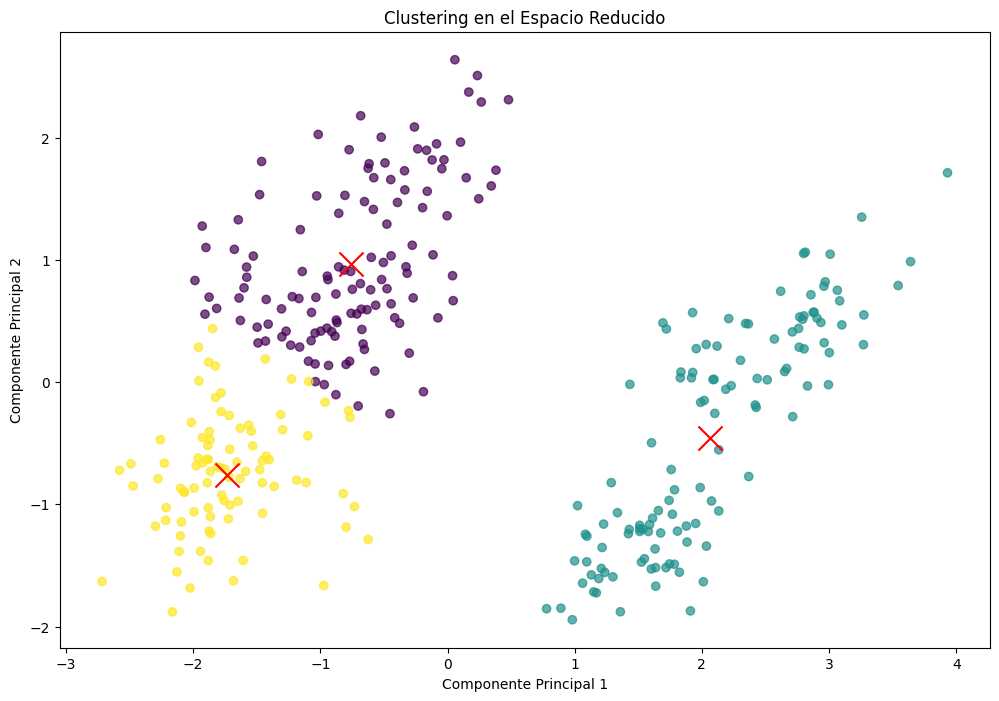

In [44]:
# Verificar si hay NaNs y hacer imputaciones
nan_counts = df.isna().sum()
print(nan_counts)
nan_rows = df.isna().any(axis=1).sum()
print(f'Filas con al menos un valor NaN: {nan_rows}')

# Rellenar NaNs en columnas numéricas con la media
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
means = df[numeric_columns].mean()
df[numeric_columns] = df[numeric_columns].fillna(means)

# Eliminar filas con NaNs en las columnas categóricas
categorical_columns = ['species', 'island', 'sex']
filas_antes_categoricas = len(df)
df.dropna(subset=categorical_columns, inplace=True)
filas_despues_categoricas = len(df)
filas_eliminadas_categoricas = filas_antes_categoricas - filas_despues_categoricas
print(f'Se eliminaron {filas_eliminadas_categoricas} filas por valores NaN en columnas categóricas.')

# Definir columnas categóricas y numéricas
categorical_columns = ['island', 'sex']  # Eliminamos 'species' ya que es la variable objetivo
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Codificación numérica de variables categóricas y escalamiento de las numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(), categorical_columns)
    ]
)

# Definir las etiquetas (y) y las características (X)
y = df["species"]
X = df.drop(columns=["species"])

# Aplicar la transformación a las características
X_transformed = preprocessor.fit_transform(X)

# Separación en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)
print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')

# Convertir las etiquetas categóricas en numéricas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f'Valores codificados de y: {np.unique(y_encoded)}')

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Crear un scatter plot usando los valores numéricos de las etiquetas
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species')
plt.title('PCA con 2 Componentes Principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Clustering en el espacio de características completo usando el Método del Codo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_transformed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo para el Espacio de Características Completo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# Clustering con K-Means en el espacio reducido (PCA)
optimal_clusters = 3  # Se puede ajustar según el gráfico del codo
kmeans_reduced = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters_reduced = kmeans_reduced.fit_predict(X_pca)

# Visualización del Clustering en el Espacio Reducido
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_reduced, cmap='viridis', alpha=0.7)
centroids_reduced = kmeans_reduced.cluster_centers_
plt.scatter(centroids_reduced[:, 0], centroids_reduced[:, 1], s=300, c='red', marker='x')
plt.title('Clustering en el Espacio Reducido')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()


In [45]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


## Misión 5: predicción de la especie

In [46]:
# Entrenar el modelo RandomForest para la predicción tradicional
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluar el modelo en el conjunto de prueba
y_pred = rf_model.predict(X_test)
accuracy_traditional = accuracy_score(y_test, y_pred)
print(f'Exactitud del modelo tradicional: {accuracy_traditional}')


Exactitud del modelo tradicional: 1.0


In [47]:
# Entrenar el modelo RandomForest para la predicción tradicional
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluar el modelo en el conjunto de prueba
y_pred = rf_model.predict(X_test)

# Calcular más métricas de rendimiento
accuracy_traditional = accuracy_score(y_test, y_pred)
f1_traditional = f1_score(y_test, y_pred, average='weighted')
roc_auc_traditional = roc_auc_score(pd.get_dummies(y_test), pd.get_dummies(y_pred), multi_class='ovr')

print(f'Exactitud del modelo tradicional: {accuracy_traditional}')
print(f'F1 Score del modelo tradicional: {f1_traditional}')
print(f'ROC AUC del modelo tradicional: {roc_auc_traditional}')

# Matriz de confusión
conf_matrix_traditional = confusion_matrix(y_test, y_pred)
print(f'Matriz de confusión:\n {conf_matrix_traditional}')

# Reporte de clasificación
class_report_traditional = classification_report(y_test, y_pred)
print(f'Reporte de clasificación:\n {class_report_traditional}')


Exactitud del modelo tradicional: 1.0
F1 Score del modelo tradicional: 1.0
ROC AUC del modelo tradicional: 1.0
Matriz de confusión:
 [[31  0  0]
 [ 0 13  0]
 [ 0  0 23]]
Reporte de clasificación:
               precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [48]:
# Crear una columna binaria que discrimina entre Gentoo y las otras dos especies en el conjunto de entrenamiento
y_binary_gentoo_train = y_train.apply(lambda x: 1 if x == 'Gentoo' else 0)

# Entrenar el primer modelo para diferenciar entre Gentoo y las otras dos especies
model1 = LogisticRegression(random_state=42)
model1.fit(X_train, y_binary_gentoo_train)

# Predecir si los pingüinos son Gentoo o no en el conjunto de prueba
y_pred_gentoo = model1.predict(X_test)

# Filtrar las predicciones que no son Gentoo para entrenar el segundo modelo
X_train_non_gentoo = X_train[y_train != 'Gentoo']
y_train_non_gentoo = y_train[y_train != 'Gentoo']

X_test_non_gentoo = X_test[y_pred_gentoo == 0]
y_test_non_gentoo = y_test[y_pred_gentoo == 0]

# Entrenar el segundo modelo para discriminar entre Adelie y Chinstrap
model2 = LogisticRegression(random_state=42)
model2.fit(X_train_non_gentoo, y_train_non_gentoo)

# Predecir las especies de los pingüinos no Gentoo
y_pred_non_gentoo = model2.predict(X_test_non_gentoo)

# Unir las predicciones finales
y_pred_hierarchical = ['Gentoo' if pred == 1 else 'Non-Gentoo' for pred in y_pred_gentoo]

# Asignar las predicciones de 'Adelie' y 'Chinstrap' donde y_pred_gentoo es 0
non_gentoo_indices = [i for i, pred in enumerate(y_pred_gentoo) if pred == 0]

for i, idx in enumerate(non_gentoo_indices):
    y_pred_hierarchical[idx] = y_pred_non_gentoo[i]

# Evaluar el rendimiento del modelo jerárquico
accuracy_hierarchical = accuracy_score(y_test, y_pred_hierarchical)
print(f'Exactitud del modelo jerárquico: {accuracy_hierarchical}')



Exactitud del modelo jerárquico: 1.0


In [49]:
# Predecir en el conjunto de prueba usando el modelo jerárquico
accuracy_hierarchical = accuracy_score(y_test, y_pred_hierarchical)
f1_hierarchical = f1_score(y_test, y_pred_hierarchical, average='weighted')
roc_auc_hierarchical = roc_auc_score(pd.get_dummies(y_test), pd.get_dummies(y_pred_hierarchical), multi_class='ovr')

print(f'Exactitud del modelo jerárquico: {accuracy_hierarchical}')
print(f'F1 Score del modelo jerárquico: {f1_hierarchical}')
print(f'ROC AUC del modelo jerárquico: {roc_auc_hierarchical}')

# Matriz de confusión
conf_matrix_hierarchical = confusion_matrix(y_test, y_pred_hierarchical)
print(f'Matriz de confusión del modelo jerárquico:\n {conf_matrix_hierarchical}')

# Reporte de clasificación
class_report_hierarchical = classification_report(y_test, y_pred_hierarchical)
print(f'Reporte de clasificación del modelo jerárquico:\n {class_report_hierarchical}')


Exactitud del modelo jerárquico: 1.0
F1 Score del modelo jerárquico: 1.0
ROC AUC del modelo jerárquico: 1.0
Matriz de confusión del modelo jerárquico:
 [[31  0  0]
 [ 0 13  0]
 [ 0  0 23]]
Reporte de clasificación del modelo jerárquico:
               precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [50]:
# Usar el análisis PCA reducido para encontrar subgrupos dentro de una especie
species_adelie = df[df['species'] == 'Adelie']

# Aplicar K-Means para agrupar Adelie en subgrupos
kmeans_adelie = KMeans(n_clusters=2, random_state=42)
clusters_adelie = kmeans_adelie.fit_predict(species_adelie[numeric_columns])

# Entrenar un modelo para predecir el subgrupo de Adelie
X_train_adelie = species_adelie[numeric_columns]
y_train_adelie = clusters_adelie

model_subgroup = RandomForestClassifier(random_state=42)
model_subgroup.fit(X_train_adelie, y_train_adelie)

# Evaluar el modelo de subgrupos en Adelie
y_pred_subgroup = model_subgroup.predict(X_train_adelie)
accuracy_subgroup = accuracy_score(y_train_adelie, y_pred_subgroup)
print(f'Exactitud del modelo de subgrupos en Adelie: {accuracy_subgroup}')

Exactitud del modelo de subgrupos en Adelie: 1.0


In [51]:
# Evaluar el rendimiento del modelo de subgrupos en Adelie
accuracy_subgroup = accuracy_score(y_train_adelie, y_pred_subgroup)
f1_subgroup = f1_score(y_train_adelie, y_pred_subgroup, average='weighted')
roc_auc_subgroup = roc_auc_score(pd.get_dummies(y_train_adelie), pd.get_dummies(y_pred_subgroup), multi_class='ovr')

print(f'Exactitud del modelo de subgrupos en Adelie: {accuracy_subgroup}')
print(f'F1 Score del modelo de subgrupos en Adelie: {f1_subgroup}')
print(f'ROC AUC del modelo de subgrupos en Adelie: {roc_auc_subgroup}')

# Matriz de confusión
conf_matrix_subgroup = confusion_matrix(y_train_adelie, y_pred_subgroup)
print(f'Matriz de confusión de subgrupos:\n {conf_matrix_subgroup}')

# Reporte de clasificación
class_report_subgroup = classification_report(y_train_adelie, y_pred_subgroup)
print(f'Reporte de clasificación de subgrupos:\n {class_report_subgroup}')


Exactitud del modelo de subgrupos en Adelie: 1.0
F1 Score del modelo de subgrupos en Adelie: 1.0
ROC AUC del modelo de subgrupos en Adelie: 1.0
Matriz de confusión de subgrupos:
 [[71  0]
 [ 0 75]]
Reporte de clasificación de subgrupos:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        75

    accuracy                           1.00       146
   macro avg       1.00      1.00      1.00       146
weighted avg       1.00      1.00      1.00       146



## Conlusión

Que todos los modelos predictivos den un resultado de 1.0 sea una señal de que el conjunto de datos es relativamente sencillo o presenta características altamente diferenciables entre las clases. Si los patrones en los datos son lo suficientemente claros y bien definidos, es razonable que un modelo, como un Random Forest o cualquier otro algoritmo de clasificación robusto, pueda aprender esos patrones con facilidad y clasificarlos correctamente en todos los casos.